<a href="https://colab.research.google.com/github/Crispin26/AI-Security-Labs/blob/main/Lab8_PGD_Attack_Robustness_Stress_Test_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**THE ROBUSTNESS STRESS TEST**

**Objective**: we Act as a Security Auditor to test the robustness of Inception v3 model
by comparing a one-step attack (FGSM) vs a multi-step attack (PGD) using the same
perturbation budget (ε = 8).

In [2]:
#Import all the required libraries
import torch
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("All libraries imported successfully!")

Using device: cuda
All libraries imported successfully!


Step 1 : WE load the Pre-Trained Model. We use *Inception v3*, a deep learning network trained on ImageNet(1000 classees). We set it to evaluation mode so it bahavees as a classifier, not a learner

In [3]:
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
model.eval()
model = model.to(device)
print("Inception v3 loaded and moved to", device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 154MB/s] 


Inception v3 loaded and moved to cuda


In [22]:
# ============================================
# Helper function to load and preprocess a LOCAL image
# ============================================
def load_image_and_preprocess(image_path):
    # Open image directly from the local path
    img = Image.open(image_path).convert('RGB')

    preprocess = transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    img_tensor = preprocess(img)
    return img_tensor.unsqueeze(0).to(device)

print("Helper function updated to handle local files!")

Helper function updated to handle local files!


***Step 2 : load and Preprocess the Test Image*** :
We download a sample image from the internett and resize it to 299x299 pixels, which is the input size Inception v3 expects. We also convert it to a Pytorch tensor.


## The PGD Attack Function

In [5]:
# ============================================
# PGD Attack Function
# ============================================
# image     → the clean input image (normalized)
# label     → the correct class label
# model     → the neural network we are attacking
# epsilon   → maximum allowed perturbation (our "budget")
# alpha     → step size for each iteration
# iters     → number of attack steps

def pgd_attack(image, label, model, epsilon, alpha, iters):
    # Start with a copy of the original image
    perturbed_image = image.clone().detach().requires_grad_(True)

    for i in range(iters):
        # Forward pass: get model's prediction on perturbed image
        outputs = model(perturbed_image)

        # Calculate loss: how correct is the model?
        # We want to MAXIMIZE this to fool the model
        loss = F.cross_entropy(outputs, label)

        # Backward pass: compute gradient of loss w.r.t. each pixel
        loss.backward()

        # Update the image: move each pixel in the direction
        # that increases the loss (fools the model more)
        with torch.no_grad():
            perturbed_image = perturbed_image + alpha * perturbed_image.grad.sign()

            # Project: make sure total perturbation stays within epsilon budget
            perturbation = torch.clamp(perturbed_image - image, -epsilon, epsilon)
            perturbed_image = image + perturbation

        # Reset gradients for next iteration
        perturbed_image = perturbed_image.detach().requires_grad_(True)

    return perturbed_image.detach()

print("PGD attack function defined!")

PGD attack function defined!


## Step A: FGSM Attack (1 step) vs Step B: PGD Attack (10 steps)
Both use the same total budget ε = 8/255, but PGD breaks it into smaller steps.

In [24]:
# ============================================
# Load the test image and get original prediction
# ============================================
image_path = "/content/my_dog.jpg"
original_image_tensor = load_image_and_preprocess(image_path)

# Get the model's prediction on the clean image
model.eval()
with torch.no_grad():
    outputs_original = model(original_image_tensor)
predicted_label = torch.argmax(outputs_original, dim=1)
original_confidence = F.softmax(outputs_original, dim=1)[0, predicted_label].item()

print(f"Original prediction: class {predicted_label.item()}")
print(f"Original confidence: {original_confidence:.4f}")

# ============================================
# Attack parameters
# ============================================
epsilon = 8/255  # Total perturbation budget

# Step A: FGSM (1 step, full budget at once)
alpha_A = 8/255
iters_A = 1

# Step B: PGD (10 steps, budget split into small steps)
alpha_B = 0.8/255
iters_B = 10

# ============================================
# Run Step A: FGSM attack
# ============================================
image_for_attack_A = original_image_tensor.clone().detach().requires_grad_(True)
adv_image_A = pgd_attack(image_for_attack_A, predicted_label, model, epsilon, alpha_A, iters_A)
print("Step A (FGSM) complete!")

# ============================================
# Run Step B: PGD attack
# ============================================
image_for_attack_B = original_image_tensor.clone().detach().requires_grad_(True)
adv_image_B = pgd_attack(image_for_attack_B, predicted_label, model, epsilon, alpha_B, iters_B)
print("Step B (PGD) complete!")

Original prediction: class 180
Original confidence: 0.3066
Step A (FGSM) complete!
Step B (PGD) complete!


## Visualization: Clean vs Adversarial Images
Comparing the clean image, the magnified perturbation (noise), and the adversarial image
for both FGSM (Step A) and PGD (Step B).

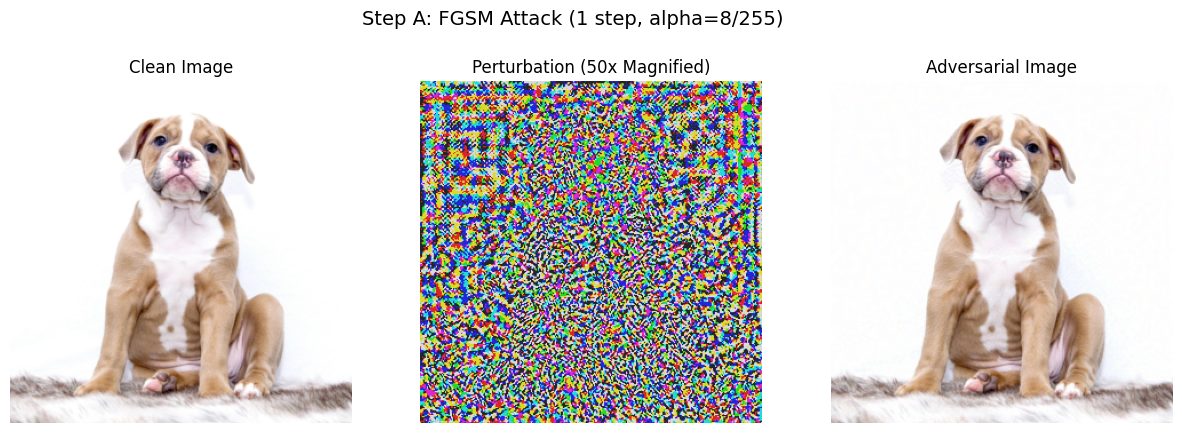

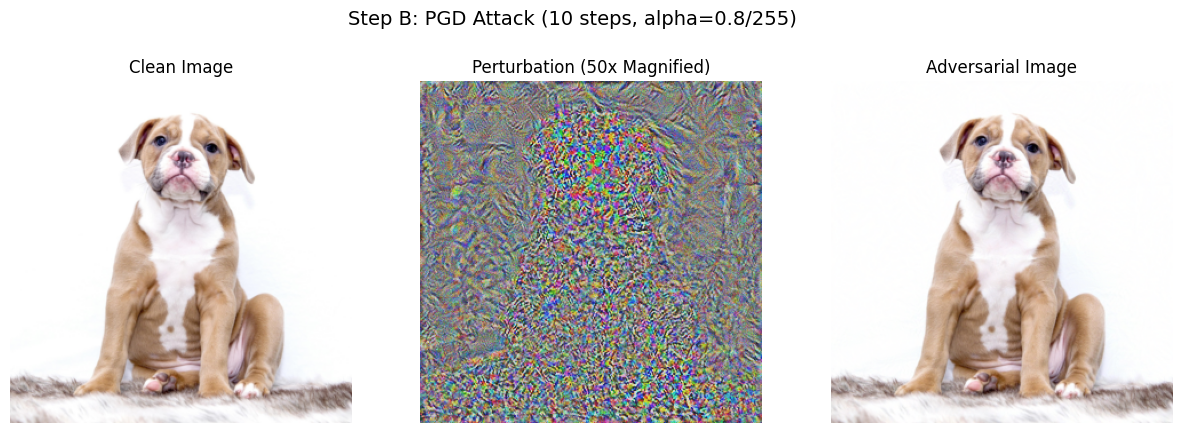

In [25]:
# ============================================
# Visualize: Clean vs Adversarial images
# ============================================
# inv_normalize undoes the normalization so we can display the image properly
# (because we normalized during preprocessing, pixels are shifted/scaled
#  and would look weird without reversing it)

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# Prepare display versions of all images
original_display = inv_normalize(original_image_tensor.squeeze(0).clone()).unsqueeze(0)
adv_display_A = inv_normalize(adv_image_A.squeeze(0).clone()).unsqueeze(0)
adv_display_B = inv_normalize(adv_image_B.squeeze(0).clone()).unsqueeze(0)

perturbation_A = adv_display_A - original_display
perturbation_B = adv_display_B - original_display

# --- Step A: FGSM Results ---
plt.figure(figsize=(15, 5))
plt.suptitle("Step A: FGSM Attack (1 step, alpha=8/255)", fontsize=14)

plt.subplot(1, 3, 1)
plt.title("Clean Image")
plt.imshow(original_display.squeeze().permute(1, 2, 0).cpu().clamp(0, 1))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Perturbation (50x Magnified)")
plt.imshow((perturbation_A.squeeze().permute(1, 2, 0).cpu() * 50 + 0.5).clamp(0, 1))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Adversarial Image")
plt.imshow(adv_display_A.squeeze().permute(1, 2, 0).cpu().clamp(0, 1))
plt.axis('off')
plt.show()

# --- Step B: PGD Results ---
plt.figure(figsize=(15, 5))
plt.suptitle("Step B: PGD Attack (10 steps, alpha=0.8/255)", fontsize=14)

plt.subplot(1, 3, 1)
plt.title("Clean Image")
plt.imshow(original_display.squeeze().permute(1, 2, 0).cpu().clamp(0, 1))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Perturbation (50x Magnified)")
plt.imshow((perturbation_B.squeeze().permute(1, 2, 0).cpu() * 50 + 0.5).clamp(0, 1))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Adversarial Image")
plt.imshow(adv_display_B.squeeze().permute(1, 2, 0).cpu().clamp(0, 1))
plt.axis('off')
plt.show()

##Accuracy Comparison : FGSM vs PGD
comparing how much the model's confidence drops under each attack,
even though both use the same total perturbation budget (ε = 8/255)

Attack               Predicted Class    Confidence     
Clean (No Attack)    180                0.3066
FGSM (1 step)        242                0.0008
PGD (10 steps)       242                0.0000

Confidence drop from FGSM: 0.3058
Confidence drop from PGD:  0.3066


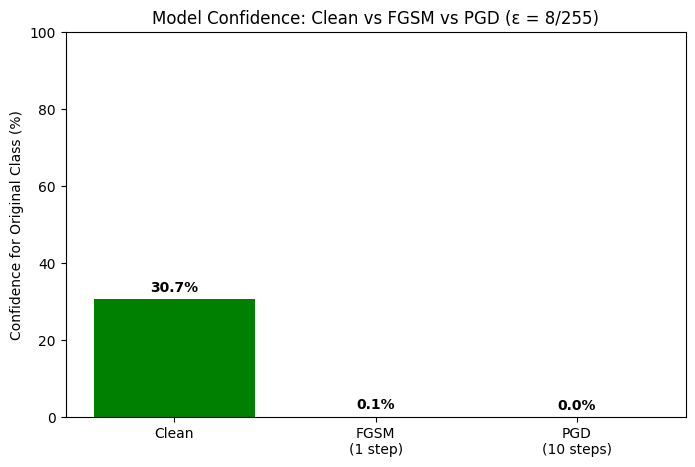

In [26]:
# ============================================
# Compare model confidence under both attacks
# ============================================
with torch.no_grad():
    out_A = model(adv_image_A)
    out_B = model(adv_image_B)

pred_A = torch.argmax(out_A, dim=1)
conf_A = F.softmax(out_A, dim=1)[0, predicted_label].item()

pred_B = torch.argmax(out_B, dim=1)
conf_B = F.softmax(out_B, dim=1)[0, predicted_label].item()

# Data Table
print("=" * 60)
print(f"{'Attack':<20} {'Predicted Class':<18} {'Confidence':<15}")
print("=" * 60)
print(f"{'Clean (No Attack)':<20} {predicted_label.item():<18} {original_confidence:.4f}")
print(f"{'FGSM (1 step)':<20} {pred_A.item():<18} {conf_A:.4f}")
print(f"{'PGD (10 steps)':<20} {pred_B.item():<18} {conf_B:.4f}")
print("=" * 60)
print(f"\nConfidence drop from FGSM: {(original_confidence - conf_A):.4f}")
print(f"Confidence drop from PGD:  {(original_confidence - conf_B):.4f}")

# Bar Chart
labels = ['Clean', 'FGSM\n(1 step)', 'PGD\n(10 steps)']
confidences = [original_confidence * 100, conf_A * 100, conf_B * 100]
colors = ['green', 'orange', 'red']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, confidences, color=colors)
plt.ylabel('Confidence for Original Class (%)')
plt.title('Model Confidence: Clean vs FGSM vs PGD (ε = 8/255)')
plt.ylim(0, 100)
for i, v in enumerate(confidences):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()